In [2]:
# Pull first 5 data entries to look at format, possible issues, and what columns are available for analysis.
import pandas as pd

pd.set_option("display.max_colwidth", None)

df = pd.read_csv("../data/raw/heels_listings.csv")
df.head()

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
0,v1|327293758920|0,Vintage pinup Stiletto Heels Polka Dot Bow Ankle Strap Open Toe,Heels,40.00,https://api.ebay.com/buy/browse/v1/item/v1%7C327293758920%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/5nYAAeSwan9qcQt6/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327293758920_0.jpg
1,v1|158096242487|459340279961,Vintage Black Multi-Strap Knee-High Caged Gladiator Heels with Buckle ws1907046,Heels,77.99,https://api.ebay.com/buy/browse/v1/item/v1%7C158096242487%7C459340279961,New with box,https://i.ebayimg.com/images/g/E6kAAeSwws5qW7oE/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_158096242487_459340279961.jpg
2,v1|257659835442|0,Vintage Y2K BCBG Strappy Sandals Heels 7.5 FLAWS,Heels,58.98,https://api.ebay.com/buy/browse/v1/item/v1%7C257659835442%7C0,Pre-owned - Fair,https://i.ebayimg.com/images/g/M9MAAeSwwHJqMdjT/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_257659835442_0.jpg
3,v1|168350814249|0,Vtg Coup D’etat Camel Color Heel Pumps Size 7.5B,Heels,29.00,https://api.ebay.com/buy/browse/v1/item/v1%7C168350814249%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/jWMAAeSwhANp95MA/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_168350814249_0.jpg
4,v1|398240323736|0,Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B,Heels,129.99,https://api.ebay.com/buy/browse/v1/item/v1%7C398240323736%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/nUkAAeSwhQNqbrNw/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_398240323736_0.jpg


In [3]:
# Check the shape of the dataframe to see how many rows and columns are present.
df.shape

(1162, 8)

In [4]:
# Pull column names to see what data is available for analysis.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1162 entries, 0 to 1161
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   itemId            1162 non-null   str    
 1   title             1162 non-null   str    
 2   specificCategory  1162 non-null   str    
 3   price             1162 non-null   float64
 4   itemURL           1162 non-null   str    
 5   condition         1162 non-null   str    
 6   imageURL          1162 non-null   str    
 7   image_local_path  1160 non-null   str    
dtypes: float64(1), str(7)
memory usage: 72.8 KB


In [5]:
# Look at summary statistics
df.describe()

,price
count,1162.000000
mean,70.788012
std,82.661002
min,7.000000
25%,26.550000
50%,40.000000
75%,77.057500
max,899.000000


Large range is not necessarily an anomaly given the presence of luxury heels. 
Interesting to see that most shoes average around ~$70; this is most likely representative of eBay's user/seller audience.
I would expect options like TheRealReal to have more luxury shoes, and a higher mean, and Depop to be similar to eBay's range.

In [6]:
df.isnull().sum()

itemId              0
title               0
specificCategory    0
price               0
itemURL             0
condition           0
imageURL            0
image_local_path    2
dtype: int64

In [7]:
# Checking both ends of data to see outliers and possible data entry errors.
df.sort_values("price", ascending=True).head(10)

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
1083,v1|168371212741|0,VTG Y2K Charlotte Russe Silver Braided Sandals Summer Beach Greek Toga Metallic,Sandals,7.00,https://api.ebay.com/buy/browse/v1/item/v1%7C168371212741%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/G64AAeSwyFxqA7HL/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_168371212741_0.jpg
950,v1|327292428516|0,Crown Vintage Remy Womend Sz 7.5 Strappy Sandals Black Faux Leather Buckle Shoes,Sandals,7.99,https://api.ebay.com/buy/browse/v1/item/v1%7C327292428516%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/RnYAAeSwGs1qb9sZ/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327292428516_0.jpg
97,v1|117293725136|0,Vintage Sam & Libby High Heel Dress Sandals 6M Excellent Condition Black Velvet,Heels,7.99,https://api.ebay.com/buy/browse/v1/item/v1%7C117293725136%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/ZQYAAeSwTSpo1D34/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_117293725136_0.jpg
652,v1|257247151573|0,Vintage high heels - metallic gold material - great condition,Heels,8.00,https://api.ebay.com/buy/browse/v1/item/v1%7C257247151573%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/MKMAAeSwPGtpNIVi/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_257247151573_0.jpg
986,v1|117300439847|0,Crown Vintage Brown Tan Bow Sandals Women 8.5,Sandals,8.00,https://api.ebay.com/buy/browse/v1/item/v1%7C117300439847%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/OzoAAeSw529qVVbB/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_117300439847_0.jpg
158,v1|176842089379|0,Vintage Vince Camuto Size 8 1/2 Color Beige Nude Small Scratches Totally Fixable,Heels,8.50,https://api.ebay.com/buy/browse/v1/item/v1%7C176842089379%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/ujUAAeSwyQVnrRVd/s-l225.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_176842089379_0.jpg
1117,v1|206436184149|0,Vintage Y2K Black Donald Pliner Slip on Wedge Sandals Elastic Stretchy Heel 6.5,Sandals,9.00,https://api.ebay.com/buy/browse/v1/item/v1%7C206436184149%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/Z4wAAeSwknFqYm10/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_206436184149_0.jpg
225,v1|287482337257|0,Vintage Ann Marino Size 7 Beige Slide Heels It’s Between White Softy Napa,Heels,9.80,https://api.ebay.com/buy/browse/v1/item/v1%7C287482337257%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/MQYAAeSwbG9qX8PX/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_287482337257_0.jpg
212,v1|236981364856|0,Vintage Selby Leather Heels Women's Size 9 1/2 90s Y2K Retro Career Office Party,Women's Vintage Shoes,9.82,https://api.ebay.com/buy/browse/v1/item/v1%7C236981364856%7C0,Pre-owned,https://i.ebayimg.com/images/g/6bQAAeSwm~NpMMca/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_236981364856_0.jpg
64,v1|206083369921|0,"Anton Donelli Vintage Brown Alligator ""Grain"" 2 In Ladies heels 9B",Women's Vintage Shoes,9.97,https://api.ebay.com/buy/browse/v1/item/v1%7C206083369921%7C0,Pre-owned,https://i.ebayimg.com/images/g/RBcAAeSw1-lpmN1r/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_206083369921_0.jpg


In [8]:
df.sort_values(by="price", ascending=False).head(10)

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path
698,v1|327293806531|0,Vintage Rudolf Scheer Sohne Bespoke Leather Riding Boots Vienna Fraktur Stamp,Men's Vintage Shoes,899.00,https://api.ebay.com/buy/browse/v1/item/v1%7C327293806531%7C0,Pre-owned,https://i.ebayimg.com/images/g/XTcAAeSw371qcRAI/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_327293806531_0.jpg
694,v1|366579623082|0,Dayton Black Beauty Motorcycle Boots Vintage - Sz 10.5 Chromexcel Triple-Sole,Boots,699.00,https://api.ebay.com/buy/browse/v1/item/v1%7C366579623082%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/IEEAAeSwqV1qOCYb/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_366579623082_0.jpg
414,v1|227457615314|0,NEW Manolo Blahnik Blue Velvet Maysale Buckle Kitten Heels Pumps Shoes 41 11,Heels,575.00,https://api.ebay.com/buy/browse/v1/item/v1%7C227457615314%7C0,New without box,https://i.ebayimg.com/images/g/0jkAAeSw459qbed0/s-l960.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_227457615314_0.jpg
26,v1|198544799309|0,Vintage 90s Miu Miu Chocolate Leather Brown Bubble Oxford Heels Sz EU 40,Heels,555.00,https://api.ebay.com/buy/browse/v1/item/v1%7C198544799309%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/LWwAAeSwsIxqcOJn/s-l1200.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_198544799309_0.jpg
27,v1|137582135088|0,Vintage Prada Crochet Mirror Mules – Size 37.5 (With Box & Dust Bag),Heels,520.00,https://api.ebay.com/buy/browse/v1/item/v1%7C137582135088%7C0,Pre-owned - Excellent,https://i.ebayimg.com/images/g/zjcAAeSwBGxqcOUy/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_137582135088_0.jpg
772,v1|377392377022|0,Vintage Justin Pig Skin Cowboy Boots | Wild Boar | USA Made | Men’s 7 D,Boots,499.99,https://api.ebay.com/buy/browse/v1/item/v1%7C377392377022%7C0,New without box,https://i.ebayimg.com/images/g/-rAAAeSw0sdqcTJh/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_377392377022_0.jpg
249,v1|267746178985|0,Prada Vintage Flower Mule Sandals Green Suede Size 41 US 11 Kitten Heel Slide,Sandals,470.00,https://api.ebay.com/buy/browse/v1/item/v1%7C267746178985%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/WrQAAeSwAY9qcFGY/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_267746178985_0.jpg
7,v1|158150347274|0,Authentic VTG TOM FORD GUCCI 2004 bamboo kitten heels in rose blush size 7,Heels,455.00,https://api.ebay.com/buy/browse/v1/item/v1%7C158150347274%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/v1sAAeSwaStqcM2l/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_158150347274_0.jpg
24,v1|366583993577|0,Christian Dior Vintage Cannage Dark Grey Heels,Heels,450.00,https://api.ebay.com/buy/browse/v1/item/v1%7C366583993577%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/T84AAeSwgblqcPD~/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_366583993577_0.jpg
399,v1|157586355965|0,Vintage Louis Vuitton Y2K Kitten Heels 38,Heels,450.00,https://api.ebay.com/buy/browse/v1/item/v1%7C157586355965%7C0,Pre-owned - Fair,https://i.ebayimg.com/images/g/M3IAAeSwT41pAR1X/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_157586355965_0.jpg


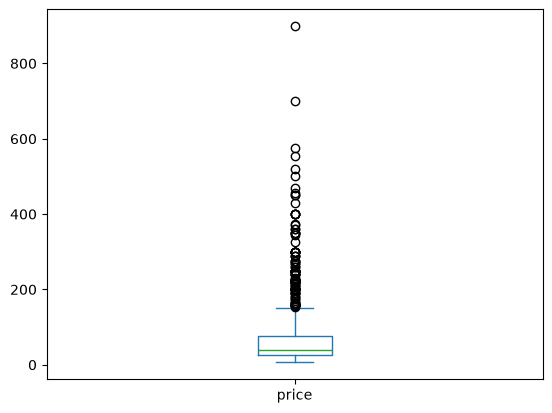

In [9]:
# Plotting a boxplot to visualize the distribution of prices.

import matplotlib.pyplot as plt

df["price"].plot(kind="box")
plt.show()

Although there are lots of "outliers", these are still valid data points; just the result of a high variation in shoes being sold.

In [10]:
# Checking eBay categories to see if there are any that are not relevant to the analysis.
df["specificCategory"].unique()

<StringArray>
[                      'Heels',       'Women's Vintage Shoes',
               'Comfort Shoes',                     'Sandals',
                       'Boots',                    'Slippers',
                'Bridal Shoes',                       'Pumps',
      'Bags, Handbags & Cases',                       'Flats',
               'Western Boots',    'Children's Vintage Shoes',
         'Men's Vintage Shoes',               'Women's Boots',
                       'Socks',                'Casual Shoes',
 'Other Japanese Collectibles']
Length: 17, dtype: str

In [11]:
# Removing invalid categories from the dataframe to focus on relevant data for analysis.
valid_categories = ["Heels", "Bridal Shoes", "Women's Vintage Shoes", "Pumps", "Women's Boots"]
df = df[df["specificCategory"].isin(valid_categories)]

In [12]:
df["specificCategory"].unique()

<StringArray>
['Heels', 'Women's Vintage Shoes', 'Bridal Shoes', 'Pumps', 'Women's Boots']
Length: 5, dtype: str

In [13]:
# Checking formatting of titles to begin working on size extraction.
df["title"].sample(20).tolist()

['Vintage Sam & Libby High Heel Dress Sandals 6M Excellent Condition Black Velvet',
 '$450 Sergio Zelcer White Leather Flower Slingback Heels Vintage sz 9 Day-Dinner',
 'Vintage Y2K J. Renee Classy Slingback Pumps Matte Gold Rhinestone Heels Size 7M',
 'Vintage 1980s Bruno Magli Slingback Leather Kitten Heels Made in Italy With Box',
 'Jimmy Choo Black Eel Skin Gilbert Pumps  Almond Toe Stiletto Heels Vintage 37.5',
 'Italian-made vintage St. Vicina blue & cream strappy stilettos - 10',
 'Vintage Lace Up Gladiator Sandals Womens 6 Leather Costume Theater',
 'Vintage 90s Y2K Classic Black Suede Mary Jane Block Heel Pumps Size 9M',
 'Vintage Flings Heels Size 6.5B W/ Box Excellent Cond',
 'Vintage Stuart Weitzman Brown Leather Kitten Heel Pumps Size 9 Ladies Shoes',
 'Vintage Talbots Ronie7 Antique Bronze Leather Kitten Heel Pumps 10M NIB',
 'Vintage Color Pump Bruno Magli Red/Black Leather Heels Gold Silver Bow ITALY 5',
 'Authentic VTG TOM FORD GUCCI 2004 bamboo kitten heels in rose bl

In [14]:
# Testing regex pattern to extract shoe sizes from titles. 
# The pattern looks for a number (which may include a decimal) followed by an optional letter (like D, E, etc.) which is common in shoe sizing.
import re

title = "Vintage Apart Leather Pumps Womens 8.5 Beige Bow Square Toe Business Career"
match = re.search(r"\d+(\.\d+)?[A-Z]?", title)
print(match.group() if match else "No match found")

8.5


In [15]:
title2 = "Vtg Stuart Weitzman Leopard Patent Leather Kitten Low Block Heel Square Toe 8.5N"
match2 = re.search(r"\d+(\.\d+)?[A-Z]?", title2)
print(match2.group() if match2 else "No match found")

8.5N


In [16]:
# Checking for possible issues with regex patterns, namely with date values in names.
title3 = "Vintage 1990's Rodolphe Menudier Slingbacks with Steel Stiletto Heels"
match3 = re.search(r"\d+(\.\d+)?[A-Z]?", title3)
print(match3.group() if match3 else "No match found")

1990


In [17]:
# Refining and testing regex pattern against multiple titles.
pattern = r"\b\d{1,2}(\.\d+)?[A-Z]?\b"
match = re.search(pattern, title)
match2 = re.search(pattern, title2)
match3 = re.search(pattern, title3)
match4 = re.search(pattern, "VTG Womans Fendi Brown Suede Kitten Heel Mules in Box Size IT 38.5,Heels,115.00")
print(match.group() if match else "No match found")
print(match2.group() if match2 else "No match found")
print(match3.group() if match3 else "No match found")
print(match4.group() if match4 else "No match found")

8.5
8.5N
No match found
38.5


In [18]:
# Creating a function to extract shoe sizes from titles using the refined regex pattern.
def extract_size(title: str) -> str | None:
    """
    Extract shoe size from a product title and return size.
    If no size is found, return None.
    """
    match = re.search(r"\b\d{1,2}(\.\d+)?[A-Z]?\b", title)
    return match.group() if match else None

df["size"] = df["title"].apply(extract_size)
df[["title", "size"]].sample(15)

,title,size
372,Vintage Delman Black Mesh Sling Back Kitten Heels Women’s Size 9.5A,9.5A
342,Vintage Eddie Bauer Suede Kitten Heel Loafers Square Toe Tan Women’s 8M,8M
416,Vintage 1980s Flings White Leather Kitten heels Size 10,10
184,Vintage Nina Comfort Black Satin Slingback Block Heels 7M Square Toe Y2K,7M
313,Vtg Stuart Weitzman Leopard Patent Leather Kitten Low Block Heel Square Toe 8.5N,8.5N
15,Vtg 70's Brown Leather Strappy Slingback Cut Out Ankle Strap Hippie Heels Size 8,70
477,GUESS by Marciano Sparkle Vintage Heels Size 6.5,6.5
121,Parallele 7 Pointed Toe Patent Leather Khaki Nude Heels Slingback Vintage 90s,7
501,Vintage Giorgio Armani Beige Pointed Toe Ankle Strap Leather Stiletto Pumps 39,39
171,Salvatore Ferragamo Vintage Cream Leather Pumps Size 7 AAAA Italy LUX Narrow,7


When pulling multiple tables, I noticed that titles with phrases like 90s, 80s, etc. were getting misinterpreted as sizes.
Therefore, a more comprehensive extract_size function needs to be created that deals with all of these possible errors.

In [19]:
def extract_size(title: str) -> str | None:
    """
    Extract shoe size from a product title and return size. 
    If no size is found, return None.
    """
    # Normalize fractions like "6 1/2" into "6.5" before matching
    title = re.sub(r"(\d+)s+1/2", lambda m: str(float(m.group(1)) + 0.5), title)

    # 1. Most confident: explicit "Size" followed by a number (+ optional letters)
    match = re.search(r"size\s*(\d{1,2}(?:\.\d+)?[A-Z]{0,2})", title, re.IGNORECASE)
    if match:
        return match.group(1)

    # 2. Next best: a number with a width number attached (decades don't have this)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?[A-Z]{1,2}\b", title)
    if match:
        return match.group()

    # 3. Fallback: a bare number, but not if followed by an 's (rules out decades)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?\b(?!'?s)", title)
    if match:
        return match.group()

    # 4. Fallback 2: a bare number, but not if followed by an s (rules out decades)
    match = re.search(r"\b\d{1,2}(?:\.\d+)?\b(?!s)", title, re.IGNORECASE)
    if match:
        return match.group()

    return None

test_titles =  [
    "S1 Vintage Paloma Black White Polka Dot Pumps Heels 7AA Made in Italy",
    "Bally Vintage Multicolor Womans Snakeskin Leather Heels,  Ankle Strap Size 6 1/2",
    "Allure Vintage 80's Pump Heels Gray Suede Womens 8.5",
    "Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed",
    "Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B",
    "Vtg 60s Palter Debs Ostrich Patent Leather Pumps Heels Brown 7.5 Classy  Retro,Heels,25.88",
]

for t in test_titles:
    print(extract_size(t), "|", t)

7AA | S1 Vintage Paloma Black White Polka Dot Pumps Heels 7AA Made in Italy
6 | Bally Vintage Multicolor Womans Snakeskin Leather Heels,  Ankle Strap Size 6 1/2
8.5 | Allure Vintage 80's Pump Heels Gray Suede Womens 8.5
7.5 | Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed
8B | Vintage Salvatore Ferragamo Boutique black leather heel pump women's size 8B
7.5 | Vtg 60s Palter Debs Ostrich Patent Leather Pumps Heels Brown 7.5 Classy  Retro,Heels,25.88


In [20]:
# Applying the extract_size function to the dataframe to create a new column for shoe sizes.
df["size"] = df["title"].apply(extract_size)

In [21]:
# Checking how many entries have null values in the "size" column after extraction.
int(df["size"].isnull().sum())

80

The amount here is negligible, and makes sense as some entries did not include size.
I am confident in my extract_size function.

In [22]:
# Checking a sample of the dataframe to see the extracted sizes alongside titles.
df[["title", "size"]].sample(20)

,title,size
426,🎨 ARCHIVAL GRAIL Vintage 90s Moschino Beaded Suede Mules - 6/36,6
416,Vintage 1980s Flings White Leather Kitten heels Size 10,10
384,Vintage Stuart Weitzman Brown Leather Kitten Heel Pumps Size 9 Ladies Shoes,9
401,Stuart Weitzman Vintage 90s Pump Satin Rhinestone Pointed Toe Black 2in US 8 B,8
449,Vtg Gucci Black Patent Leather GG Logo Kitten Heels 36.5,36.5
456,Stuart Weitzman Women's 8B Tan Leather Corset Lace Vintage Kitten Heels,8B
399,Vintage Louis Vuitton Y2K Kitten Heels 38,38
625,Allure Vintage 80's Pump Heels Purple Womens Size 7.5 Abstract Modern Pointed,7.5
587,Vtg Y2K Anne Klein Red Satin Rhinestone Buckle Pointed Toe Stiletto Mules Sz 7.5,7.5
436,Vintage 90s Giraudon Kitten Heels Sandals 37 / 6.5 Leather Lace Up Twee Coquette,37


In [23]:
# Checking a sample of titles that did not have sizes extracted to see if there are any patterns or issues with the regex.
df[df["size"].isnull()]["title"].sample(30).tolist()

['Vintage 1980s Bruno Magli Slingback Leather Kitten Heels Made in Italy With Box',
 'BUMPER Brown Studded Zip Synthetic Stiletto Pumps Closed Toe-Vintage*',
 'Vintage Michael Kors Black Patent Leather Stilettos',
 "2026 Women's Retro Dress Leather Cuban Heel Lace Up Shoes Mary Jane Pumps Office",
 'Vintage Y2K Calvin Klein Black Patent Strappy Slingback Kitten Heels',
 "Bandolino Flawless Vintage Women's Stiletto Heels Beige Buckle Accent Tweed.",
 "Women's Velvet Vintage-Inspired heels NEW never worn- Made in Spain",
 'Vintage Black Morgan De Toi kitten heels with white & black fur accents',
 'Vintage  DeLiso Mauve Suede Women’s Peep-Toe Heels In Original Box',
 'Vintage NOS Dead Stock Fiancees Classic Black Patent Leather Stiletto Heels MCM',
 'NIB Vintage 90s Donald J Pliner Heels Leather Flower Glitter With Box Susan-6060',
 'Vintage pinup Stiletto Heels Polka Dot Bow Ankle Strap Open Toe',
 'Nine West Paolo Batacchi pearl Leather Square Toe Block Heel Pumps Spain vintage',
 'Vint

In [24]:
# Pulling a random sample of titles to build a brand list to reference against for a brand extraction function. 
# This will help in identifying brand names in the titles for further analysis.
df["title"].sample(30).tolist()

['Vintage Billy Ella Velvet Burgundy/ Red Slingback Heels Sz 8',
 'Diane Von Furstenberg Kinder Cork Ankle Strap Heel Womens Size 8 Tan Leather',
 'VINTAGE NINE WEST KITTEN HEEL - LEATHER & REAL COWHIDE  - SIZE 5.5',
 'Dolce Gabbana Rose Floral Satin Vintage Kitten Heels Sz EU 39 1/2 US 8.5 y2k',
 'Red satin high heels, round toes, vintage, size 8, (#1022)',
 'St. John Vintage Size 7.5 B Pistachio Pump White Details Made In Italy',
 'Vtg 90s Y2K Round Toe Kitten Heels Mules Womens Sz 7 Dark Whimsigoth Velvet',
 'Spicy Snake Print Stiletto Heels - Size 8.5-Vintage',
 "Talbots Vintage 90's Women's Ella Navy Leather Chunky Gold Buckle Peep Toe Pumps",
 'Etienne Aigner Vintage Brown Kitten Heels Logo Chocolate Brown Coquette Preppy',
 'Vintage high heels - metallic gold material - great condition',
 'Vintage Prada Crochet Mirror Mules – Size 37.5 (With Box & Dust Bag)',
 'Vintage Black Leather Woven Strappy Stiletto Heels, Ann Marino, Size 8.5',
 'Vintage Paloma Italy Black Polka Dot Sling

In [25]:
# First attempt at creating a list of brands from the sample titles. 
# This list was refined and used to extract brand names from the product titles in the dataset.
""" brands = [
    "BCBG",
    "Coup D'etat",
    "Salvatore Ferragamo",
    "Manolo Blahnik",
    "PRADA",
    "Bally Suite",
    "Stuart Weitzman",
    "Barney's",
    "Connie",
    "Andrea",
    "Delman",
    "Ann Marino",
    "Alfani",
    "Giuseppe Zanotti",
    "Christian Dior",
    "Anne Klein",
    "Miu Miu",
    "Robert Clergerie",
    "Timothy Hitsman",
    "Burberry",
    "Nine West",
    "Etienne Aigner",
    "Thom McAn",
    "Emilio Pucci",
    "Escada",
    "Evan Picone",
    "J. Renee",
    "Calvin Klein",
    "Andrew Geller",
    "Ava Ferragamo",
    "Anton Donelli",
    "St. John",
    "Pancaldi",
    "Amanda Smith",
    "Coach",
    "Gucci",
    "Naturalizer",
    "Previa",
    "Bandolino",
    "Betsey Johnson",
    "ZARA",
    "Livingston Bros",
    "John Romaine",
    "Sam & Libby",
    "Botticelli",
    "Talbots x Caressa",
    "Hillard & Hanson",
    "Bruno Magli",
    "Unisa Keyana",
    "Christian Siriano",
    "Charles David",
    "Chanel",
    "Jennifer Moore",
    "Liz Claiborne",
    "Amano",
    "Madden",
    "Bijou",
    "MIA",
    "Kenneth Cole",
    "Margaret J",
    "YSL Saint Laurent",
    "Dolce Zuriel",
    "Vince Camuto",
    "MIchelle D. Brown",
    "Joan & David Brown",
    "Merona",
    "BCBGirls",
    "Pimento",
    "Maggie Sweet",
    "Donna Karan",
    "Moschino",
    "Isaac Mizrahi",
    "Susan Bennis/Warren Edwards",
    "Thos Cortito",
    "Evan-Picone",
    "St. John",
    "Cole Haan",
    "Stuart Weitzman",
    "Hillard & Hanson",
    "Bandolino",
    "Christian Lacroix",
    "Amano",
    "Ralph Lauren",
    "Naturalizer",
    "Adrianna Papell",
    "Rosa",
    "Bakers Marisela",
    "FREE Lance",
    "Nine West",
    "Boutique 9 BT Joy",
    "Allure",
    "Cobbie Cuddlers",
    "Merona",
    "Martinez Valero",
    "Shimano",
    "LEI",
    "Candies",
    "Enzo Angiolini",
    "Sesto Meucci",
    "Amalfi Rangoni",
    "Dolce & Gabbana",
    "Donald J Pliner",
    "Coach",
    "Socialite",
    "Perry ellis",
    "Diane Von Furstenberg",
    "Carlos Santana",
    "Seventeen",
    "Baldinini",
    "Palizzio",
    "Prima",
    "Michelle D",
    "Via Spiga",
    "Norman Kapan",
    "Marc Fisher Dabney",
    "California Magdesians",
    "Emporio Armani",
    "Martinez Valero",
    "Colin Stuart",
    "Proxy",
    "Giorgio Armani",
    "L'Autre",
    "Dolce by Pierre White",
    "Jones New York",
    "Beverly Feldman",
    "Vero Cudio",
    "Liz Claiborne",
    "Laundry By Shelli",
    "Morgan De Toi",
    "Leather Creators",
    "Charles Jourdan",
    "New Wave",
    "Paloma",
    "Caparros",
    "Talbots",
    "Amano",
    "Carlos Falchi",
    "Kenneth Cole",
    "Michelle D Brown",
    "Rodolphe Menudier",
    "Coccini",
    "Miss Bergdorf",
    "Two Lips",
    "Franco Sarto",
    "Parallele",
    "Newport",
    "Caressa",
    "Dolce Gabbana",
    "Ann-Marino",
    "Oscar de la renta",
    "Circa Joan & David",
    "Selby",
    "Ballt",
    "De liso",
    "Nordstrom",
    "Vaneli",
    "IMPO ",
    "Valerie Stevens",
    "Mima Italy",
    "Sutton plaza",
    "Mr. Phillips",
    "Kenzo",
    "Saks Fifth Avenue",
    "St. Vicina",
    "Trotters",
    "Aerosoles",
    "Maserati",
    "Brighton",
    "Deliso",
    "Buccioni by Cosci",
    "Easyspirit",
    "Norman Kaplan",
    "Rocawear",
    "Ellen Tracey",
    "Garolini",
    "Carole Little",
    "Diego Dolcini",
    "Guess",
    "Prevata",
    "Billy Ella",
    "Easy spirit",
    "Fioni",
    "Palter Debs",
    "Pappagallo",
    "BCB Girls",
    "Fendi",
    "Wild Diva",
    "Roberto Capucci",
    "Michael Kors",
    "Salpy",
    "Van Eli",
    "Nickels",
    "Cleo Bottier",
    "A Marinelli",
    "Marco Brelli",
    "BALLY",
    "Amalfi",
    "Diego Di Lucca",
    "Sergio Zelcer",
    "GaLo",
    "Yves Saint Laurent YSL",
    "Colette",
    "Circa Joan and David",
    "Icone",
    "Idea Studio",
    "Fiorangelo",
    "Dollhouse",
    "Romus",
    "Luichiny",
    "Y. Renee",
    "Marc by Marc Jacobs",
    "Louis Vuitton",
    "Kate Spade",
    "Fanfares",
    "Mario Bologna",
    "Givenchy",
    "A. Marinelli",
    "Charlotte Russe",
    "Adrienne",
    "Madamoiselle",
    "Mootsies Tootsies",
    "Sabreé",
    "Dione",
    "Juicy Couture",
    "Boutique 9",
    "Nando Muzi",
    "Nine-west",
    "Harve Benard",
    "Monzo & Franco",
    "WILD PAIR",
    "Bettye Mueller",
    "Ferragamo",
    "Walter Steiger",
    "Mootsie Tootsie",
    "Lara Manni",
    "Jimmy Choo",
    "Fabulous Furs",
    "Juliano",
    "RioWomen's",
    "Unisa",
    "Jean Paul Barriol",
    "No Boundaries",
    "Classiques Entier",
    "Nina",
    "BALDAN",
    "BUMPER",
    "Dream Step",
    "Ann Taylor",
    "Cameo Room",
    "TOUCH-UPS",
    "Joyce Brown",
    "Chloe",
    "Roma Last Marquise",
    "Versani",
    "Brocade",
    "Barney's",
    "Nicole Miller",
    "SPICY",
    "Vanna",
    "BODEN",
    "Audrey",
    "KF Ltd",
    "St John",
    "Rapallo",
    "Barbie",
    "Crown",
    "Apple Bottoms",
    "Linea Paolo",
    "Bratz",
    "JG Hook",
    "Timothy's Collection",
    "Chelsea Crew",
    "Coup D'etat",
    "Elena Miro",
    "Jacqueline Ferrar",
    "Giraudon",
    "Eddie Bauer",
    "Balenciaga",
    "Tweedies",
    "Joan & David",
    "Karen Scott",
    "La Patti",
    "Anne Michelle",
    "Tory Burch",
    "Donald Pliner",
    "Pencey Neiman",
    "Barney's",
    "Off-White",
    "Magdesians",
    "Gap",
    "Birkenstock",
    "Fashion Nova",
    "Maripe",
    "Richard Tyler",
    "LARIO",
    "Fergalicious",
    "Gianni Binni",
    "Auditions",
    "Florsheim",
    "Salvatore Ferragammo",
    "Edouard Jerrold",
    "Dolce&Gabbana",


]

brands = list(set(brands))
print(len(brands))"""

' brands = [\n    "BCBG",\n    "Coup D\'etat",\n    "Salvatore Ferragamo",\n    "Manolo Blahnik",\n    "PRADA",\n    "Bally Suite",\n    "Stuart Weitzman",\n    "Barney\'s",\n    "Connie",\n    "Andrea",\n    "Delman",\n    "Ann Marino",\n    "Alfani",\n    "Giuseppe Zanotti",\n    "Christian Dior",\n    "Anne Klein",\n    "Miu Miu",\n    "Robert Clergerie",\n    "Timothy Hitsman",\n    "Burberry",\n    "Nine West",\n    "Etienne Aigner",\n    "Thom McAn",\n    "Emilio Pucci",\n    "Escada",\n    "Evan Picone",\n    "J. Renee",\n    "Calvin Klein",\n    "Andrew Geller",\n    "Ava Ferragamo",\n    "Anton Donelli",\n    "St. John",\n    "Pancaldi",\n    "Amanda Smith",\n    "Coach",\n    "Gucci",\n    "Naturalizer",\n    "Previa",\n    "Bandolino",\n    "Betsey Johnson",\n    "ZARA",\n    "Livingston Bros",\n    "John Romaine",\n    "Sam & Libby",\n    "Botticelli",\n    "Talbots x Caressa",\n    "Hillard & Hanson",\n    "Bruno Magli",\n    "Unisa Keyana",\n    "Christian Siriano",\n    

While/after building my brand_extraction function, I found this brand list to be very flawed. 
I initially included typos/different spellings, and included brands multiple times.
I realized that it would be hard to consolidate brands with typos (making sure Ferragammo and Ferrragammmo were counted as the same brand),
so I revised my list and created a fuzzy matching function to consolidate these typos/error cases.

In [26]:
brands = [
"BCBG",
"Coup D'etat",
"Salvatore Ferragamo",
"Manolo Blahnik",
"PRADA",
"Bally Suite",
"Stuart Weitzman",
"Barney's",
"Connie",
"Andrea",
"Delman",
"Ann Marino",
"Alfani",
"Giuseppe Zanotti",
"Christian Dior",
"Anne Klein",
"Miu Miu",
"Robert Clergerie",
"Timothy Hitsman",
"Burberry",
"Nine West",
"Etienne Aigner",
"Thom McCann",
"Emilio Pucci",
"Escada",
"Evan Picone",
"J. Renee",
"Calvin Klein",
"Andrew Geller",
"Ava Ferragamo",
"Anton Donelli",
"St. John",
"Pancaldi",
"Amanda Smith",
"Coach",
"Gucci",
"Naturalizer",
"Previa",
"Bandolino",
"Betsey Johnson",
"ZARA",
"Livingston Bros",
"John Romaine",
"Sam & Libby",
"Botticelli",
"Talbots x Caressa",
"Hillard & Hanson",
"Bruno Magli",
"Unisa Keyana",
"Christian Siriano",
"Charles David",
"Chanel",
"Jennifer Moore",
"Liz Claiborne",
"Amano",
"Madden",
"Bijou",
"MIA",
"Kenneth Cole",
"Margaret J",
"YSL Saint Laurent",
"Dolce Zuriel",
"Vince Camuto",
"Michelle D Brown",
"Joan & David",
"Merona",
"BCBGirls",
"Pimento",
"Maggie Sweet",
"Donna Karan",
"Moschino",
"Isaac Mizrahi",
"Susan Bennis/Warren Edwards",
"Thos Cortito",
"Cole Haan",
"Christian Lacroix",
"Ralph Lauren",
"Adrianna Papell",
"Rosa",
"Bakers Marisela",
"FREE Lance",
"Boutique 9 BT Joy",
"Allure",
"Cobbie Cuddlers",
"Martinez Valero",
"Shimano",
"LEI",
"Candies",
"Enzo Angiolini",
"Sesto Meucci",
"Amalfi Rangoni",
"Dolce & Gabbana",
"Donald J Pliner",
"Socialite",
"Perry Ellis",
"Diane Von Furstenberg",
"Carlos Santana",
"Seventeen",
"Baldinini",
"Palizzio",
"Prima",
"Michelle D",
"Via Spiga",
"Norman Kaplan",
"Marc Fisher Dabney",
"California Magdesians",
"Emporio Armani",
"Colin Stuart",
"Proxy",
"Giorgio Armani",
"L'Autre",
"Dolce by Pierre White",
"Jones New York",
"Beverly Feldman",
"Vero Cudio",
"Laundry By Shelli",
"Morgan De Toi",
"Leather Creators",
"Charles Jourdan",
"New Wave",
"Paloma",
"Caparros",
"Talbots",
"Carlos Falchi",
"Rodolphe Menudier",
"Coccini",
"Miss Bergdorf",
"Two Lips",
"Franco Sarto",
"Parallele",
"Newport",
"Caressa",
"Circa Joan & David",
"Selby",
"Ballt",
"Deliso",
"Nordstrom",
"Vaneli",
"IMPO",
"Valerie Stevens",
"Mima Italy",
"Sutton plaza",
"Mr. Phillips",
"Kenzo",
"Saks Fifth Avenue",
"St. Vicina",
"Trotters",
"Aerosoles",
"Maserati",
"Brighton",
"Buccioni by Cosci",
"Easy Spirit",
"Rocawear",
"Ellen Tracey",
"Garolini",
"Carole Little",
"Diego Dolcini",
"Guess",
"Prevata",
"Billy Ella",
"Fioni",
"Palter Debs",
"Pappagallo",
"Fendi",
"Wild Diva",
"Roberto Capucci",
"Michael Kors",
"Salpy",
"Nickels",
"Cleo Bottier",
"A. Marinelli",
"Marco Brelli",
"BALLY",
"Amalfi",
"Diego Di Lucca",
"Sergio Zelcer",
"GaLo",
"Colette",
"Idea Studio",
"Fiorangelo",
"Dollhouse",
"Romus",
"Luichiny",
"Marc by Marc Jacobs",
"Louis Vuitton",
"Kate Spade",
"Fanfares",
"Mario Bologna",
"Givenchy",
"Charlotte Russe",
"Adrienne",
"Madamoiselle",
"Mootsies Tootsies",
"Sabreé",
"Dione",
"Juicy Couture",
"Boutique 9",
"Nando Muzi",
"Harve Benard",
"Monzo & Franco",
"WILD PAIR",
"Bettye Mueller",
"Walter Steiger",
"Lara Manni",
"Jimmy Choo",
"Fabulous Furs",
"Juliano",
"RioWomen's",
"Unisa",
"Jean Paul Barriol",
"No Boundaries",
"Classiques Entier",
"Nina",
"BALDAN",
"BUMPER",
"Dream Step",
"Ann Taylor",
"Cameo Room",
"TOUCH-UPS",
"Joyce Brown",
"Chloe",
"Roma Last Marquise",
"Versani",
"Brocade",
"Nicole Miller",
"SPICY",
"Vanna",
"BODEN",
"Audrey",
"KF Ltd",
"Rapallo",
"Barbie",
"Crown",
"Apple Bottoms",
"Linea Paolo",
"Bratz",
"JG Hook",
"Timothy's Collection",
"Chelsea Crew",
"Elena Miro",
"Jacqueline Ferrar",
"Giraudon",
"Eddie Bauer",
"Balenciaga",
"Tweedies",
"Joan & David",
"Karen Scott",
"La Patti",
"Anne Michelle",
"Tory Burch",
"Pencey Neiman",
"Off-White",
"Gap",
"Birkenstock",
"Fashion Nova",
"Maripe",
"Richard Tyler",
"LARIO",
"Fergalicious",
"Gianni Binni",
"Auditions",
"Icone",
"Florsheim",
"Edouard Jerrold",
"Gianni Bini",

]

brands = list(set(brands))
print(len(brands))


264


In [124]:
# Creating a function to extract brand names from product titles using the list of known brands. 
def extract_brand(title: str) -> str | None:
    """
    Extract brand name from a product title and return brand. 
    If no brand is found, return None.
    """
    for brand in brands:
        if re.search(rf"\b{re.escape(brand)}\b", title, re.IGNORECASE):
            return brand
    return None

df["brand"] = df["title"].apply(extract_brand)

In [125]:
df["brand"].isnull().sum()

np.int64(157)

In [126]:
df[["title", "brand"]].sample(20)

,title,brand
132,"Bally Vintage Multicolor Womans Snakeskin Leather Heels, Ankle Strap Size 6 1/2",BALLY
666,Vintage silver pumps with gold sequins,NaN
383,Pumps Vintage Y2K Goth BCBGirls Women 7 Black Square Toe Bow Kitten Heels 3in,BCBGirls
275,Vintage Stuart Weitzman Black Open Toe Kitten Heel Mule Sandals Sz 8.5 Buckle,Stuart Weitzman
485,VTG Bally Womens Brown Suede Pointed Toe Slingback Heels Power City Work Sz 7.5,BALLY
506,Rare Vintage BCBG ITALIAN Black Leather Croc Heels 7.5 B,BCBG
636,Vintage Nicole Miller Leather Scalloped Slip On Stiletto Heel Retro Mule 6 B,Nicole Miller
307,"Vintage Salvatore Ferragamo Calfskin Leather ""Carla"" Kitten Heels Size 5 1/2",Salvatore Ferragamo
435,Vintage Stuart Weitzman Women's Toucan Taupe Crepe Fabric Kitten Heels Size 8.5,Stuart Weitzman
280,Vtg Y2K Ann Taylor Blue Pointed Toe Kitten Heel Mules Floral Embroidery 7.5 90's,Ann Taylor


In [127]:
df[df["brand"].isnull()]["title"].sample(40).tolist()

["Women's Mid Block Heel Slip On Round Toe Retro Wing Tip Formal Pumps Shoes Plus",
 'Stunning Vintage BCB Girls Blue Kitten Heels with Silver Buckle. Size 6.5 B',
 'Vintage women’s Pumps Heels Shoes Yellow',
 'VTG Kitten Heels Slate Blue Genuine Eel Skin Peep Toe Slingback Sz 5.5 Handmade',
 'VTG Red python Slingback Kitten Heels  8.5m  Cushioned Leather Rare',
 'Vtg Coup D’etat Camel Color Heel Pumps Size 7.5B',
 'Vintage Y2K Kitten Heels Size 8.5 White Pearl Iridescent  Open Toe Sanctuary',
 'VTG Nine-West “Elsa” Pumps Black Suede w/Tassels-&-CROC Accent Size 7.5 NIB',
 'Brown Croc Embossed T-Strap Kitten Heels 6.5 Vintage Inspired Leather Sandals',
 'Vintage Womens Heels 5.5 Black Fuzzy Peep Toe Chic Wedding Guest Event Formal',
 'Vintage 1950’s Women’s 6 Black Fabric Strappy Pointed Toe Stiletto Slip On Heels',
 'Vintage 90s early 2000s red genuine leather square toe chunky block kitten heels',
 'Chunky Wet High Heel Women Black 8.5 Y2K 2000 Stiletto Platform 90’s Every Day',
 'RA

In [128]:
%pip install rapidfuzz

from rapidfuzz import process

canonical_brands = list(set(brands))

def fuzzy_match_brand(name: str, threshold: int = 70) -> str | None:
    if not name:
        return None
    match = process.extractOne(name, canonical_brands)
    if match and match[1] >= threshold:
        return match[0]
    return name

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3.14t.exe -m pip install --upgrade pip


In [129]:
df["brand"] = df["brand"].apply(fuzzy_match_brand)

In [130]:
pd.options.display.max_rows = 300
df["brand"].value_counts()

brand
Stuart Weitzman                32
Salvatore Ferragamo            18
Bruno Magli                    13
PRADA                          11
Anne Klein                     11
St. John                       10
Etienne Aigner                  9
Nine West                       7
Talbots                         7
Ann Marino                      6
Bandolino                       6
Kenneth Cole                    6
Escada                          5
Amalfi                          5
BALLY                           5
Kate Spade                      5
BCBG                            4
Manolo Blahnik                  4
BCBGirls                        4
Donald J Pliner                 4
Cole Haan                       4
Dolce & Gabbana                 4
Gucci                           3
Andrea                          3
Delman                          3
Evan Picone                     3
J. Renee                        3
Naturalizer                     3
Betsey Johnson                  3
Hillard 

In [131]:
print(fuzzy_match_brand("Salvatore Ferragammo"))

Salvatore Ferragamo


In [132]:
print(fuzzy_match_brand("BCB Girls"))

BCBGirls


In [133]:
print(fuzzy_match_brand("Dolce by Pierre"))

Dolce by Pierre White


In [134]:
print(fuzzy_match_brand("Magdesians"))

California Magdesians


In [135]:
# pull data to build color matching function
df["title"].sample(30).tolist()

["Vintage Y2K Kitten Heels Slingback Pumps Women's 6.5 K+S Shoes Chocolate Brown",
 'Vintage Stuart Weitzman Seymour Black Lace Stiletto Pumps Heels Shoes Size 5.5',
 'Prada Vintage Y2K Black Buckle Pumps Size 37.5 US 7 6.5',
 'Vintage Ann Marino Black Suede Open Toe Slingback Heels Size 8.5 Evening Pumps',
 'Florsheim Signature Red Leather Pumps Vintage Almond Toe Kitten Heels 8B',
 "VTG Amalfi Rangoni Women's Plaid Peep Toe Heels Italian Leather Lined 7.5  NIB",
 'Slingback Heels Y2K Glam Monzo & Franco Women 9 Red Beaded Pointed Toe Vintage',
 'Vintage Vero Cudio Gunmetal Bronze Y2K Kitten Heels Slingback Buckle Sz 9.5',
 'Vintage Kate Spade Tan Perforated Leather Designer Pointed-Toe Pumps Heels 8.5B',
 'Y2K Vintage Apple Bottoms Pink Rare Grail wedge heels platforms',
 'Vintage Stuart Weitzman Brown Leather Kitten Heel Pumps Size 9 Ladies Shoes',
 'VTG Bijou Black Beaded Slingback Stiletto Pointed Toe Heels Man Made Size 8.5',
 'Vintage Delman Renaissance Jacquard Baroque Pointed 

In [136]:
colors = [
    "Purple",
    "Gold",
    "Red",
    "Black",
    "White",
    "Beige",
    "Pink",
    "Silver",
    "Tan",
    "Bronze",
    "Brown",
    "Gray",
    "Grey",
    "Blue",
    "Multicolor",
    "Yellow",
    "Green",
    "Mauve",
    "Pearl",
    "Leopard",
    "Snakeskin",
    "Croc",
    "Taupe",
    "Paisley",
    "Floral",
    "Coral",
    "Rose",
    "Orange",
    "Navy",
    "Plaid",
    "Camel",
    "Ivory",
    "Cream",
    "Various Colors",
    "Khaki",
    "Rainbow",
    "Snake print",
    "Tortoise",
    "Burgundy",
    "Blush",
    "Colorblock",

]

In [137]:
def extract_colors(title: str) -> str | None:
    found_colors = []
    for color in colors:
        if color.lower() in title.lower():
            found_colors.append(color)

    if len(found_colors) == 1:
        return found_colors[0]
    elif len(found_colors) > 1:
        return "Multicolor"
    else:
        return None

df["colors"] = df["title"].apply(extract_colors)

In [138]:
df[["title", "colors"]].sample(20)

,title,colors
273,Christian Lacroix Vintage Polka Dot Kitten Heel Sandal 38,NaN
451,Stuart Weitzman Y2K Black Pebbled Leather Bow Kitten Heel Mules Slides 8.5 38.5,Black
48,Escada Vintage Heels Black Canvas With White Pinstripe Crossover Buckle Size 5.5,Multicolor
523,Vintage Stiletto Pumps 1960s Navy Coccini Leather Women's Size 6B Custom Made,Navy
49,"NWT: VTG California Magdesians Tortoise Brown Leather Womens Heel Pump, 9 S",Multicolor
200,Vintage Bruno Magli Gold Heels 7 Peep Toe Stiletto,Gold
505,VTG Dream Step BROWN REAL LEATHER POINTED MID HEEL BOW CLASSIC PUMP SHOES Sz 8,Brown
402,Vintage BALDAN Italy Suede Pumps Green 60s 70s Kitten Heel Ribbon Bow Shoes,Green
573,Vintage Ann Marino Black Suede Open Toe Slingback Heels Size 8.5 Evening Pumps,Black
348,Vintage ANN MARINO Brown Beaded Kitten Heel Mule Sandals w/ Satin Trim. Sz 7.5M,Brown


In [139]:
df[df["colors"].isnull()]["title"].sample(20).tolist()

['Vintage Etienne Aigner Brett Leather Pumps Women’s 7.5 NLow Heel Shoes Peeling',
 'Bettye Mueller Kitten Heels Peacock Print Bow Detail Size 36  US 5.5 6 Vintage',
 'Bruno Magli Vintage 6.5 AA Leather Peep Toe Slingback Heels Italy',
 'Vintage GIVENCHY Slingback Pumps, Size 6.5, Made In Italy',
 'Betsey Johnson Nobble Womens Heels',
 'Madden NYC Women’s Size 11 Clog Heeled Comfort Slides Color Raffia New In Box',
 'Diego Di Lucca Women’s Sandals Hand Painted Vintage Shoes Size 6.5 Mule Heels',
 'Vintage Y2K Escada Strappy Logo Heel Sandals Size 38',
 'vintage etienne aigner "status" leather 2" heel slide on pumps size 6m EUC m2',
 'Marc By Marc Jacobs Kitten Heels Womens 38 7.5 Leather Boho Vintage y2k 90s',
 'NIB Vintage 90s Donald J Pliner Heels Leather Flower Glitter With Box Susan-6060',
 "Vintage Charles David Women's Mule Cow Print Square Toe Slip-On Heels 8.5",
 '2026 New Women French Vintage Studded Round Toe Mary Janes, Shallow Mouth Soft S',
 'Vtg Y2K Colin Stuart Leather S

In [140]:
sum(df["colors"].isnull())

102

In [141]:
# consolidate colors into groups
color_groups = {
    "Red": "Red",
    "Rose": "Red",
    "Burgundy": "Red",
    "Orange": "Orange",
    "Yellow": "Yellow",
    "Green": "Green",
    "Blue": "Blue",
    "Navy": "Blue",
    "Purple": "Purple",
    "Mauve": "Purple",
    "Gold": "Gold",
    "Silver": "Silver",
    "Bronze": "Bronze",
    "Multicolor": "Multicolor",
    "Various Colors": "Multicolor",
    "Rainbow": "Multicolor",
    "Colorblock": "Multicolor",
    "Black": "Black",
    "White": "White",
    "Pearl": "White",
    "Ivory": "White",
    "Cream": "White",
    "Tan": "Tan",
    "Beige": "Tan",
    "Taupe": "Tan",
    "Camel": "Tan",
    "Khaki": "Tan",
    "Brown": "Brown",
    "Pink": "Pink",
    "Blush": "Pink",
    "Coral": "Pink",
    "Gray": "Gray",
    "Grey": "Gray",
    "Leopard": "Animal Print",
    "Snakeskin": "Animal Print",
    "Snake print": "Animal Print",
    "Tortoise": "Animal Print",
    "Croc": "Animal Print",
    "Paisley": "Pattern",
    "Floral": "Pattern",
    "Plaid": "Pattern",

}

def normalize_color(colors: str | None) -> str | None:
    if colors is None:
        return None
    return color_groups.get(colors, colors)

df["colors"] = df["colors"].apply(normalize_color)

In [142]:
extract_colors("Vintage Betsey Johnson Navy Blue Red Bow Snakeskin Stiletto Y2K Heels Size 5.5")

'Multicolor'

In [143]:
df[["title","brand", "colors"]].sample(20)

,title,brand,colors
544,RARE Vintage ShoeDazzle Multicolor Heels Summer Stiletto w Strap,NaN,Multicolor
541,Vtg Y2K Valerie Stevens Val Flex Merlot Leather Crocodile Print High Heel,Valerie Stevens,Animal Print
514,St. John Black Leather Slingback Heels Size 7 Made in Italy Square Toe Pumps VTG,St. John,Black
391,Bruno Magli Vintage Women's Kitten Black Heels size 6.5 Made in Italy Shoe 0055,Bruno Magli,Black
606,Donald J Pliner Tortoise Patent Leather Heels Pumps Women’s Sz 8 Vintage,Donald J Pliner,Animal Print
326,Donna Karan Vintage 90's Dark Tangerine Patent Kitten Heel Mules 8M,Donna Karan,Tan
487,Vintage Color Pump Bruno Magli Red/Black Leather Heels Gold Silver Bow ITALY 5,Bruno Magli,Multicolor
600,"Pappagallo Brown Pumps Heels 3.5"" Peep Toe Bow Size 7.5 Leather Vintage",Pappagallo,Brown
417,Vintage Vero Cudio Gunmetal Bronze Y2K Kitten Heels Slingback Buckle Sz 9.5,Vero Cudio,Bronze
93,Zebra Print Square Toe Pumps Size 8 VTG,NaN,NaN


In [144]:
df[["title","brand", "colors", "size", "price"]].sample(20)

,title,brand,colors,size,price
354,Vtg Salvatore Ferragamo Leather Patchwork Pointed Toe Kitten Heel Size 8.5 Pumps,Salvatore Ferragamo,NaN,8.5,54.89
63,VTG Timothy Hitsman Multicolor Heels Gold Accents sz 7.5 N square heel w cut out,Timothy Hitsman,Multicolor,7.5,28.00
273,Christian Lacroix Vintage Polka Dot Kitten Heel Sandal 38,Christian Lacroix,NaN,38,89.99
218,Bellini Ontario Heels Size 7 NIB Two Color Tan & Black Vintage,NaN,Multicolor,7,24.95
549,Vintage Wild Diva Black Patent Peep Toe Heels-White Piping Detail-Stiletto 8.50,Wild Diva,Multicolor,8.50,35.00
428,Vintage 90s Y2K Black Beaded Kitten Heels Pointed Toe Sling Back City Size 7.5,NaN,Black,7.5,32.00
670,Italian-made vintage St. Vicina blue & cream strappy stilettos - 10,St. Vicina,Multicolor,10,9.99
60,90s Vintage Andrew Geller Black Leather Mules Size 6 Open Toe,Andrew Geller,Black,6,32.95
175,Maggie Sweet Pumps 8.5 Vintage 90s Square Toe Black Gold Suede Bow Block Heel,Maggie Sweet,Multicolor,8.5,29.99
516,NEW Carlos Santana Prestige Open Toe Stiletto High Heels - Vintage Red - Size 9,Carlos Santana,Multicolor,9,44.99


In [145]:
# pull data to build material extraction function
df["title"].sample(30).tolist()

['Anton Donelli Vintage Brown Alligator "Grain" 2 In Ladies heels 9B',
 "Stuart Weitzman Women's 8B Tan Leather Corset Lace Vintage Kitten Heels",
 'Vintage Icone Black Suede Heels 38.5/US 7.5 Italy Patent Bow 90s',
 '90s Vintage Andrew Geller Black Leather Mules Size 6 Open Toe',
 'Vintage Kenneth Cole Ivory Silk Bridal Pumps Spain Vero Cuoio 7B',
 'Charles David Vintage Tan Leather Pointed Toe Slingback Heels 9B Made in Spain',
 'Anne Michelle "Inferno-88" Red Snakeskin Platform Heels - Size 8.5-Vintage',
 'Vintage Delman Renaissance Jacquard Baroque Pointed Toe Kitten Pumps Heels 9',
 'Spicy Snake Print Stiletto Heels - Size 8.5-Vintage',
 'Vintage Burberry Women’s Brown Check Leather Open Toe Ankle Strap Heels Size 8',
 'Vintage 90s Palizzio Peep Toe Leather Heels Cream Womens 8 Made in Spain w/Box',
 'Womens Kitten Heel Ankle Boots Pointed Toe Side Zipper Fall Winter 9 Khaki',
 "90's 00's vintage red strappy archival y2k stiletto heels US 6B stuart weitzman",
 'Vintage Y2K 90s Col

In [146]:
materials = [
    "Leather",
    "Velvet",
    "Rhinestone",
    "Suede",
    "Wood",
    "Beaded",
    "Satin",
    "Tweed",
    "Fabric",
    "Sequin",
    "Patent Leather",
    "Fur",
    "Plastic",
    "Lace",
    "Silk",
]

In [147]:
def extract_materials(title: str) -> str | None:
    found_materials = []
    for material in materials:
        if material.lower() in title.lower():
            found_materials.append(material)

    if len(found_materials) == 1:
        return found_materials[0]
    elif len(found_materials) > 1:
        return "Multimaterial"
    else:
        return None

df["materials"] = df["title"].apply(extract_materials)

In [148]:
df[["title", "materials"]].sample(20)

,title,materials
590,Vintage Y2K BCBG MaxAzria Black Strappy Slide Stilettos Heels Shoes Size 9.5B,NaN
5,Vtg Manolo Blahnik Lace Up Sneaker Heels with Denim + White Leather size 38.5,Multimaterial
291,Vintage Y2K NOS Newport News Kitten Heel Mules Size 9 Crimson Red Suede,Suede
532,Vintage Womens Heels 5.5 Black Fuzzy Peep Toe Chic Wedding Guest Event Formal,NaN
60,90s Vintage Andrew Geller Black Leather Mules Size 6 Open Toe,Leather
407,Vintage Y2K Black Satin Mesh 70s 80s Embellished Sling Back Kitten Heels Size 8,Satin
618,"CHARLOTTE RUSSE Patent 4"" Stiletto High Heel Pointed Toe Pumps Sz 8 Purple VTG",NaN
353,Vtg Dolce & Gabbana Red Snakeskin Slingback Kitten Heels 36.5,NaN
271,Vintage Liz Claiborne Mauve Leather Mule Kitten Heels Pointed Toe 7.5M 90's/Y2K,Leather
435,Vintage Stuart Weitzman Women's Toucan Taupe Crepe Fabric Kitten Heels Size 8.5,Fabric


In [149]:
sum(df["materials"].isnull())

245

There's a higher amount of listings with no material, but that's to be expected. 

In [150]:
df[["title","brand", "colors", "size", "price", "materials"]].sample(20)

,title,brand,colors,size,price,materials
434,Anne Klein Vintage Coral Pink Snakeskin Leather Slingback Kitten Heels Sizd 7.5M,Anne Klein,Multicolor,7.5M,28.00,Leather
214,Vintage Kate Spade Tan Perforated Leather Designer Pointed-Toe Pumps Heels 8.5B,Kate Spade,Tan,8.5B,24.75,Leather
333,vintage 1990s Unisa 9 pink leather mules ribbed band kitten heels Pointed Toe,Unisa,Pink,9,28.00,Leather
42,Thom McCan black square toed leather loafers size 6,NaN,Black,6,27.00,Leather
532,Vintage Womens Heels 5.5 Black Fuzzy Peep Toe Chic Wedding Guest Event Formal,NaN,Black,5.5,28.00,NaN
486,Carlos Santana NOS Vintage Black Stiletto Heels Closed Toe Pumps Minor Flaw Shoe,Carlos Santana,Multicolor,NaN,50.00,NaN
502,Vintage 90s Palizzio Peep Toe Leather Heels Cream Womens 8 Made in Spain w/Box,Palizzio,White,8,40.00,Leather
286,Vintage Linea Paolo Kitten heels pearl/white,Linea Paolo,Multicolor,NaN,17.49,NaN
433,Vintage Kenneth Cole d'Orsay Black Kitten Heel Point Toe Size 9,Kenneth Cole,Black,9,35.99,NaN
321,Vintage Summer RioWomen’s Studded Black Suede Kitten Heels Size 8,NaN,Black,8,45.00,Suede


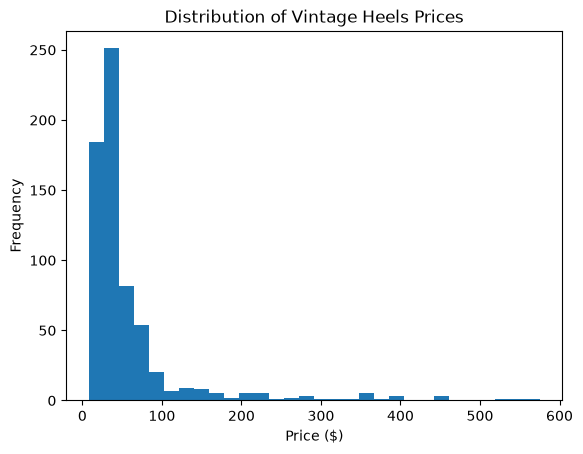

In [151]:
import matplotlib.pyplot as plt

df["price"].plot(kind="hist", bins=30)
plt.xlabel("Price ($)")
plt.title("Distribution of Vintage Heels Prices")
plt.show()

Most of the listings are in the under $100, around $40-$70 roughly.
There are a few outliers which are most likely 'grail' items (aka extremely rare or valuable luxury items).

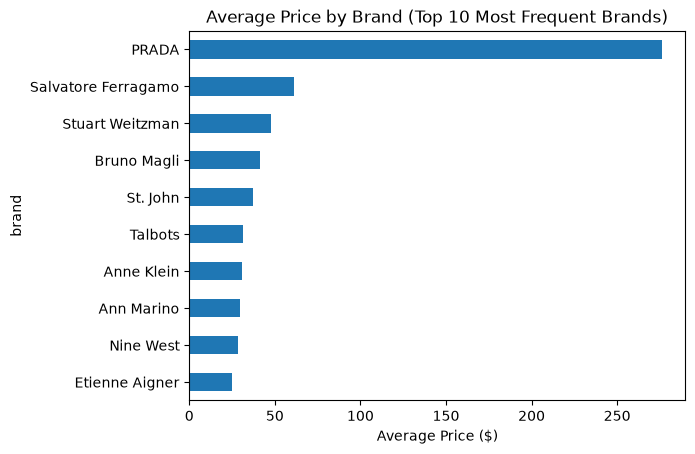

In [152]:
top_brands = df["brand"].value_counts().head(10).index
df[df["brand"].isin(top_brands)].groupby("brand")["price"].mean().sort_values().plot(kind="barh")
plt.xlabel("Average Price ($)")
plt.title("Average Price by Brand (Top 10 Most Frequent Brands)")
plt.show()  

There's a large price difference between Prada shoes and the rest of the top 10 brands. 
I need to check if LEI is actually that common or if it's mistakenly grouping Calvin Klein and Anne Kleine into the LEI brand. 

In [153]:
df[df["brand"] == "LEI"]

,itemId,title,specificCategory,price,itemURL,condition,imageURL,image_local_path,size,brand,colors,materials
58,v1|158151411348|0,Vintage LEI Brown Suede Fringe Mule Clogs | Y2K Wooden Heel | Women's Size 7,Heels,42.0,https://api.ebay.com/buy/browse/v1/item/v1%7C158151411348%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/xg8AAeSwVktqamzP/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_158151411348_0.jpg,7,LEI,Brown,Multimaterial
211,v1|236982425918|0,Vtg LEI Brown Platform Loafer Heels Chunky Heel Buckle Y2K Bratz Academia sz 7,Heels,29.0,https://api.ebay.com/buy/browse/v1/item/v1%7C236982425918%7C0,Pre-owned - Good,https://i.ebayimg.com/images/g/MicAAeSwFdNqcRdd/s-l1600.jpg,c:\Users\meime\OneDrive\Documents\vintage-heel-price-project\scrapers\..\data\images\v1_236982425918_0.jpg,7,LEI,Brown,NaN


As expected, Anne Klein and Calvin Klein were getting misrepresented as LEI, so I adjusted my brand extraction regex to adjust for that error case.

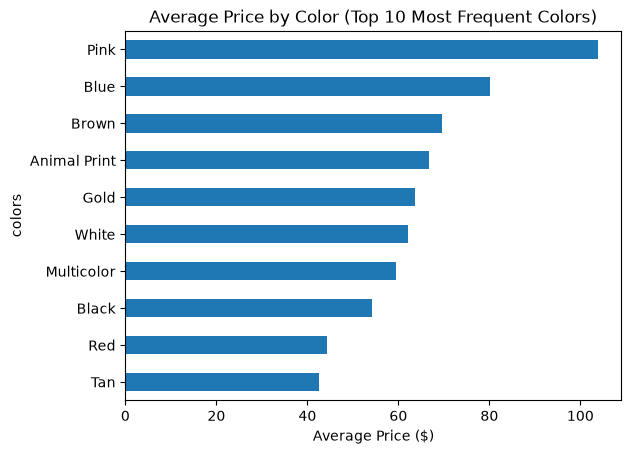

In [155]:
top_colors = df["colors"].value_counts().head(10).index
df[df["colors"].isin(top_colors)].groupby("colors")["price"].mean().sort_values().plot(kind="barh")
plt.xlabel("Average Price ($)")
plt.title("Average Price by Color (Top 10 Most Frequent Colors)")
plt.show()  

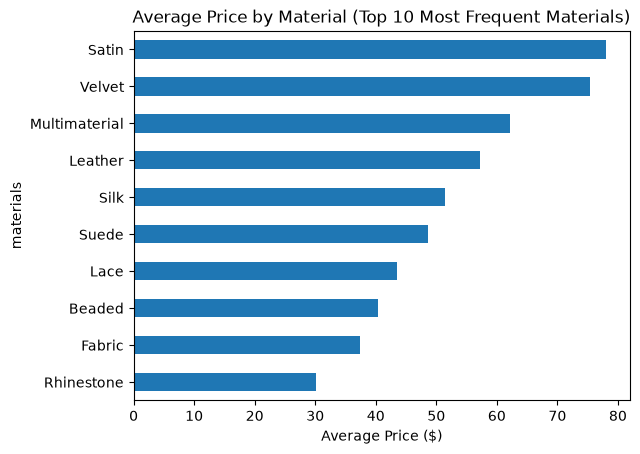

In [156]:
top_materials = df["materials"].value_counts().head(10).index
df[df["materials"].isin(top_materials)].groupby("materials")["price"].mean().sort_values().plot(kind="barh")
plt.xlabel("Average Price ($)")
plt.title("Average Price by Material (Top 10 Most Frequent Materials)")
plt.show()  

In [157]:
df.groupby("brand")["price"].agg(["mean", "count"]).sort_values("mean", ascending=False).head(15)

,mean,count
brand,,
Miu Miu,555.000000,1
Louis Vuitton,450.000000,1
Jimmy Choo,399.990000,1
Manolo Blahnik,392.497500,4
Apple Bottoms,360.000000,1
Off-White,360.000000,1
Christian Dior,285.000000,2
PRADA,275.999091,11
Balenciaga,275.000000,1


In [158]:
df.groupby("colors")["price"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
colors,,
Gray,105.625714,7
Pink,103.816471,17
Blue,80.237333,15
Brown,69.576727,55
Animal Print,66.704737,19
Gold,63.563043,23
White,62.043043,23
Multicolor,59.514500,140
Orange,59.247500,4


In [159]:
df.groupby("materials")["price"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
materials,,
Satin,78.027727,22
Velvet,75.436000,15
Multimaterial,62.140847,59
Fur,61.923333,3
Leather,57.148429,210
Silk,51.442500,4
Suede,48.634833,60
Lace,43.584545,11
Beaded,40.285714,7
